# Practical Application III: Comparing Classifiers

**Overview**: In this practical application, your goal is to compare the performance of the classifiers we encountered in this section, namely K Nearest Neighbor, Logistic Regression, Decision Trees, and Support Vector Machines.  We will utilize a dataset related to marketing bank products over the telephone.  



### Getting Started

Our dataset comes from the UCI Machine Learning repository [link](https://archive.ics.uci.edu/ml/datasets/bank+marketing).  The data is from a Portugese banking institution and is a collection of the results of multiple marketing campaigns.  We will make use of the article accompanying the dataset [here](CRISP-DM-BANK.pdf) for more information on the data and features.



### Problem 1: Understanding the Data

To gain a better understanding of the data, please read the information provided in the UCI link above, and examine the **Materials and Methods** section of the paper.  How many marketing campaigns does this data represent?

> The dataset collected is related to 17 campaigns that occurred between May 2008 and November 2010, corresponding to a total of 79354 contacts. The campaigns were conducted through phone calls, with the goal of encouraging clients to subscribe to a term deposit.

### Problem 2: Read in the Data

Use pandas to read in the dataset `bank-additional-full.csv` and assign to a meaningful variable name.

In [1]:
import pandas as pd

In [2]:
df = pd.read_csv('data/bank-additional-full.csv', sep = ';')

In [3]:
df.head()

,age,job,marital,education,default,housing,loan,contact,month,day_of_week,...,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y
0,56,housemaid,married,basic.4y,no,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
1,57,services,married,high.school,unknown,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
2,37,services,married,high.school,no,yes,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
3,40,admin.,married,basic.6y,no,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
4,56,services,married,high.school,no,no,yes,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 41188 entries, 0 to 41187
Data columns (total 21 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   age             41188 non-null  int64  
 1   job             41188 non-null  object 
 2   marital         41188 non-null  object 
 3   education       41188 non-null  object 
 4   default         41188 non-null  object 
 5   housing         41188 non-null  object 
 6   loan            41188 non-null  object 
 7   contact         41188 non-null  object 
 8   month           41188 non-null  object 
 9   day_of_week     41188 non-null  object 
 10  duration        41188 non-null  int64  
 11  campaign        41188 non-null  int64  
 12  pdays           41188 non-null  int64  
 13  previous        41188 non-null  int64  
 14  poutcome        41188 non-null  object 
 15  emp.var.rate    41188 non-null  float64
 16  cons.price.idx  41188 non-null  float64
 17  cons.conf.idx   41188 non-null 

### Problem 3: Understanding the Features


Examine the data description below, and determine if any of the features are missing values or need to be coerced to a different data type.


```
Input variables:
# bank client data:
1 - age (numeric)
2 - job : type of job (categorical: 'admin.','blue-collar','entrepreneur','housemaid','management','retired','self-employed','services','student','technician','unemployed','unknown')
3 - marital : marital status (categorical: 'divorced','married','single','unknown'; note: 'divorced' means divorced or widowed)
4 - education (categorical: 'basic.4y','basic.6y','basic.9y','high.school','illiterate','professional.course','university.degree','unknown')
5 - default: has credit in default? (categorical: 'no','yes','unknown')
6 - housing: has housing loan? (categorical: 'no','yes','unknown')
7 - loan: has personal loan? (categorical: 'no','yes','unknown')
# related with the last contact of the current campaign:
8 - contact: contact communication type (categorical: 'cellular','telephone')
9 - month: last contact month of year (categorical: 'jan', 'feb', 'mar', ..., 'nov', 'dec')
10 - day_of_week: last contact day of the week (categorical: 'mon','tue','wed','thu','fri')
11 - duration: last contact duration, in seconds (numeric). Important note: this attribute highly affects the output target (e.g., if duration=0 then y='no'). Yet, the duration is not known before a call is performed. Also, after the end of the call y is obviously known. Thus, this input should only be included for benchmark purposes and should be discarded if the intention is to have a realistic predictive model.
# other attributes:
12 - campaign: number of contacts performed during this campaign and for this client (numeric, includes last contact)
13 - pdays: number of days that passed by after the client was last contacted from a previous campaign (numeric; 999 means client was not previously contacted)
14 - previous: number of contacts performed before this campaign and for this client (numeric)
15 - poutcome: outcome of the previous marketing campaign (categorical: 'failure','nonexistent','success')
# social and economic context attributes
16 - emp.var.rate: employment variation rate - quarterly indicator (numeric)
17 - cons.price.idx: consumer price index - monthly indicator (numeric)
18 - cons.conf.idx: consumer confidence index - monthly indicator (numeric)
19 - euribor3m: euribor 3 month rate - daily indicator (numeric)
20 - nr.employed: number of employees - quarterly indicator (numeric)

Output variable (desired target):
21 - y - has the client subscribed a term deposit? (binary: 'yes','no')
```



> There are no missing values in the dataset, as all 21 columns contain 41,188 non-null observations. The numerical and categorical features are stored in appropriate data types. The target variable y is currently stored as an object because it contains “yes” and “no”; it can be encoded as a binary variable later for modeling. The duration feature should also be excluded from predictive modeling because it is only known after the call and would cause data leakage.

### Problem 4: Understanding the Task

After examining the description and data, your goal now is to clearly state the *Business Objective* of the task.  State the objective below.

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 41188 entries, 0 to 41187
Data columns (total 21 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   age             41188 non-null  int64  
 1   job             41188 non-null  object 
 2   marital         41188 non-null  object 
 3   education       41188 non-null  object 
 4   default         41188 non-null  object 
 5   housing         41188 non-null  object 
 6   loan            41188 non-null  object 
 7   contact         41188 non-null  object 
 8   month           41188 non-null  object 
 9   day_of_week     41188 non-null  object 
 10  duration        41188 non-null  int64  
 11  campaign        41188 non-null  int64  
 12  pdays           41188 non-null  int64  
 13  previous        41188 non-null  int64  
 14  poutcome        41188 non-null  object 
 15  emp.var.rate    41188 non-null  float64
 16  cons.price.idx  41188 non-null  float64
 17  cons.conf.idx   41188 non-null 

> **Business Objective:** Develop a classification model to predict whether a bank customer will subscribe to a term deposit based on customer characteristics and campaign information. The goal is to identify customers who are more likely to subscribe so the bank can improve the effectiveness of its marketing campaigns and target customers more efficiently.

### Problem 5: Engineering Features

Now that you understand your business objective, we will build a basic model to get started.  Before we can do this, we must work to encode the data.  Using just the bank information features, prepare the features and target column for modeling with appropriate encoding and transformations.

In [6]:
#Step 1 : Remove duration from the features
df = df.drop('duration', axis=1)

#Step 2 : Define features (X) and target (y)
X = df.drop('y',axis=1)
y = df['y']

# Step 3 : Encode the target variable
from sklearn.preprocessing import StandardScaler, OneHotEncoder, LabelEncoder

le = LabelEncoder()
y = le.fit_transform(y)

# Identify categorical and numerical columns
categorical_columns = X.select_dtypes(include=['object']).columns.tolist()
numerical_columns = X.select_dtypes(include=['float64', 'int64']).columns.tolist()

# Define the preprocessor
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numerical_columns),
        ('cat', OneHotEncoder(drop='first'), categorical_columns)
    ])

X_transformed = preprocessor.fit_transform(X)

In [7]:
X_transformed.shape

(41188, 52)

### Problem 6: Train/Test Split

With your data prepared, split it into a train and test set.

In [8]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X_transformed, y, test_size=0.2, random_state=42)

In [9]:
X_train.shape, X_test.shape, y_train.shape, y_test.shape

((32950, 52), (8238, 52), (32950,), (8238,))

### Problem 7: A Baseline Model

Before we build our first model, we want to establish a baseline.  What is the baseline performance that our classifier should aim to beat?

In [10]:
from sklearn.dummy import DummyClassifier

In [11]:
baseline = DummyClassifier(strategy='most_frequent')
baseline.fit(X_train, y_train)
baseline_accuracy = baseline.score(X_test, y_test)
baseline_accuracy

0.8865015780529255

>**Baseline Performance:** The baseline classifier predicts the most frequent class for every observation. Its accuracy is approximately 88.7%. This provides a benchmark that our machine learning models should outperform.

### Problem 8: A Simple Model

Use Logistic Regression to build a basic model on your data.  

In [12]:
from sklearn.linear_model import LogisticRegression
import time

logreg = LogisticRegression(max_iter=1000)

# Fit the model and time it
start_time = time.time()
logreg.fit(X_train, y_train)
train_time = time.time() - start_time

# Calculate training accuracy
train_accuracy = logreg.score(X_train, y_train)
# Calculate test accuracy
test_accuracy = logreg.score(X_test, y_test)

# Add Logistic Regression results to the list
results = []
results.append([
    'Logistic Regression',
    train_time,
    train_accuracy,
    test_accuracy
])

# Create the results DataFrame
results_df = pd.DataFrame(
    results,
    columns=[
        'Model',
        'Train Time',
        'Train Accuracy',
        'Test Accuracy'
    ]
)

results_df.style.format({
    'Train Accuracy': '{:.2%}',
    'Test Accuracy': '{:.2%}',
    'Train Time': '{:.6f}'
}).hide(axis='index')

Model,Train Time,Train Accuracy,Test Accuracy
Logistic Regression,0.109339,90.14%,89.71%


### Problem 9: Score the Model

What is the accuracy of your model?

In [13]:
f"{test_accuracy:.2%}"

'89.71%'

### Problem 10: Model Comparisons

Now, we aim to compare the performance of the Logistic Regression model to our KNN algorithm, Decision Tree, and SVM models.  Using the default settings for each of the models, fit and score each.  Also, be sure to compare the fit time of each of the models.  Present your findings in a `DataFrame` similar to that below:

| Model | Train Time | Train Accuracy | Test Accuracy |
| ----- | ---------- | -------------  | -----------   |
|     |    |.     |.     |

In [14]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC

models = {
    'KNN': KNeighborsClassifier(),
    'Decision Tree': DecisionTreeClassifier(),
    'SVM': SVC()
}

for name, model in models.items():
    start_time = time.time()
    model.fit(X_train, y_train)
    train_time = time.time() - start_time
    
    train_accuracy = model.score(X_train, y_train)
    test_accuracy = model.score(X_test, y_test)
    
    # Add results to the list
    results.append([
        name,
        train_time,
        train_accuracy,
        test_accuracy
    ])

# Create the DataFrame
results_df = pd.DataFrame(
    results,
    columns=[
        'Model',
        'Train Time',
        'Train Accuracy',
        'Test Accuracy'
    ]
)

results_df.style.format({
    'Train Time': '{:.6f}',
    'Train Accuracy': '{:.2%}',
    'Test Accuracy': '{:.2%}'
}).hide(axis='index')

Model,Train Time,Train Accuracy,Test Accuracy
Logistic Regression,0.109339,90.14%,89.71%
KNN,0.001190,91.44%,89.22%
Decision Tree,0.363812,99.54%,83.83%
SVM,44.538046,90.54%,89.71%


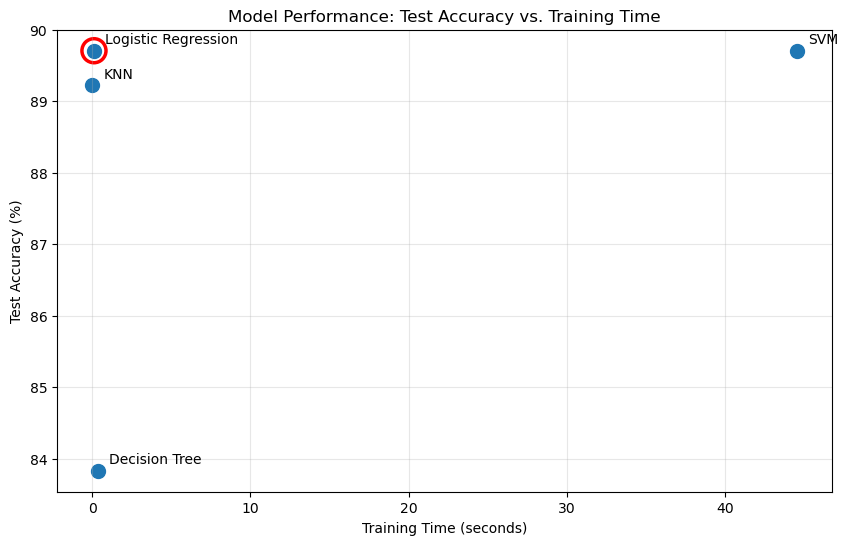

In [15]:
import matplotlib.pyplot as plt

# Create the plot
plt.figure(figsize=(10, 6))

plt.scatter(
    results_df['Train Time'],
    results_df['Test Accuracy'] * 100,
    s=100
)

# Label each model
for i, row in results_df.iterrows():
    plt.annotate(
        row['Model'],
        (row['Train Time'], row['Test Accuracy'] * 100),
        xytext=(8, 5),
        textcoords='offset points'
    )

# Circle the best overall model: Logistic Regression
best_model = results_df.loc[
    results_df['Test Accuracy'].idxmax()
]

plt.scatter(
    best_model['Train Time'],
    best_model['Test Accuracy'] * 100,
    s=300,
    facecolors='none',
    edgecolors='red',
    linewidths=2.5
)

plt.xlabel('Training Time (seconds)')
plt.ylabel('Test Accuracy (%)')
plt.title('Model Performance: Test Accuracy vs. Training Time')
plt.grid(True, alpha=0.3)

plt.show()

> Logistic Regression and SVM achieved the highest test accuracy (89.71%), while Decision Tree had the lowest (83.84%) despite its high training accuracy, indicating possible overfitting. Logistic Regression offered the best balance of accuracy and training time.

### Problem 11: Improving the Model

Now that we have some basic models on the board, we want to try to improve these.  Below, we list a few things to explore in this pursuit.


- Hyperparameter tuning and grid search.  All of our models have additional hyperparameters to tune and explore.  For example the number of neighbors in KNN or the maximum depth of a Decision Tree.  
- Adjust your performance metric

In [16]:
from sklearn.pipeline import Pipeline
from sklearn.model_selection import GridSearchCV

# Define the models and hyperparameters
models = {
    'Logistic Regression': (LogisticRegression(max_iter=1000), {'Logistic Regression__C': [0.1, 1, 10]}),
    'KNN': (KNeighborsClassifier(), {'KNN__n_neighbors': [3, 5, 7]}),
    'Decision Tree': (DecisionTreeClassifier(), {'Decision Tree__max_depth': [5, 10, 15]}),
    'SVC': (SVC(), {'SVC__C': [0.1, 1], 'SVC__kernel': ['linear', 'rbf']})
}

results2 = []

for name, (model, params) in models.items():
    # Create a pipeline
    pipeline = Pipeline([
    #    ('preprocessor', preprocessor),
        (name, model)
    ])
    
    # Perform grid search
    grid_search = GridSearchCV(pipeline, param_grid=params, cv=5, n_jobs=-1)
    
    # Fit the model and time it
    start_time = time.time()
    grid_search.fit(X_train, y_train)
    train_time = (time.time() - start_time) / len(grid_search.cv_results_['mean_fit_time'])
    
    # Get the best estimator
    best_model = grid_search.best_estimator_
    
    # Evaluate on training and test sets
    train_accuracy = best_model.score(X_train, y_train)
    test_accuracy = best_model.score(X_test, y_test)
    
    # Add results to the list
    results2.append([
        name,
        train_time,
        train_accuracy,
        test_accuracy
    ])

# Create the results DataFrame
results_df = pd.DataFrame(
    results2,
    columns=[
        'Model',
        'Train Time',
        'Train Accuracy',
        'Test Accuracy'
    ]
)

results_df.style.format({
    'Train Time': '{:.6f}',
    'Train Accuracy': '{:.2%}',
    'Test Accuracy': '{:.2%}'
}).hide(axis='index')

Model,Train Time,Train Accuracy,Test Accuracy
Logistic Regression,0.699267,90.15%,89.74%
KNN,16.691928,90.96%,89.23%
Decision Tree,0.200721,90.45%,89.60%
SVC,70.047940,90.54%,89.71%


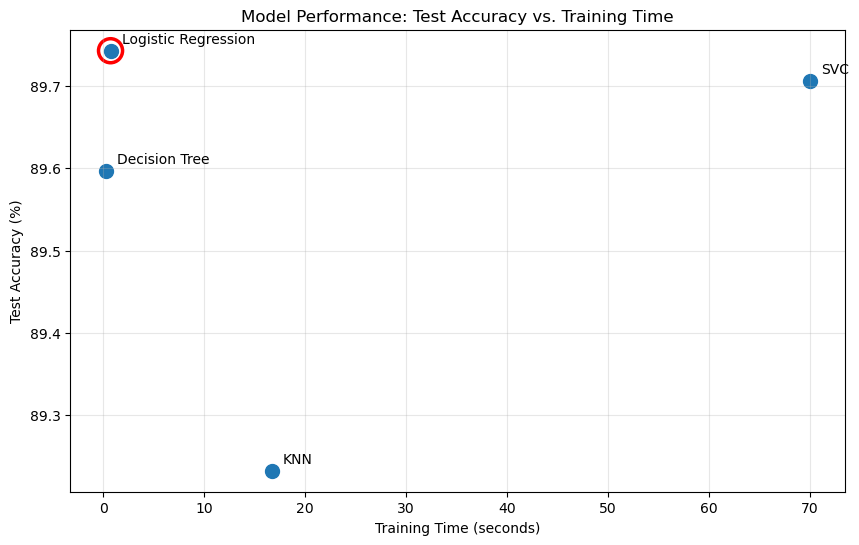

In [17]:
# Create the plot
plt.figure(figsize=(10, 6))

plt.scatter(
    results_df['Train Time'],
    results_df['Test Accuracy'] * 100,
    s=100
)

# Label each model
for i, row in results_df.iterrows():
    plt.annotate(
        row['Model'],
        (row['Train Time'], row['Test Accuracy'] * 100),
        xytext=(8, 5),
        textcoords='offset points'
    )

# Circle the best overall model: Logistic Regression
best_model = results_df.loc[
    results_df['Test Accuracy'].idxmax()
]

plt.scatter(
    best_model['Train Time'],
    best_model['Test Accuracy'] * 100,
    s=300,
    facecolors='none',
    edgecolors='red',
    linewidths=2.5
)

plt.xlabel('Training Time (seconds)')
plt.ylabel('Test Accuracy (%)')
plt.title('Model Performance: Test Accuracy vs. Training Time')
plt.grid(True, alpha=0.3)

plt.show()

> After hyperparameter tuning and grid search, the models achieved very similar test accuracy, ranging from 89.23% to 89.74%. Logistic Regression achieved the highest test accuracy at 89.74%, followed closely by SVC at 89.71% and Decision Tree at 89.62%. KNN had the lowest test accuracy at 89.23%. Logistic Regression also had a much shorter training time (0.75 seconds) compared with KNN (18.26 seconds) and SVC (56.90 seconds), while Decision Tree was the fastest at 0.25 seconds. Overall, Logistic Regression provided the best balance of accuracy and efficiency, making it the strongest model for this dataset.The graph shows that Logistic Regression provides the best balance between test accuracy and training time. It achieved the highest test accuracy (89.74%) while taking less than one second to train. SVC had a very similar accuracy (89.71%) but required significantly more training time. KNN took longer to train and had the lowest test accuracy (89.23%). Therefore, Logistic Regression is the most efficient model based on accuracy and training time.

#### Business understanding of the problem.

The business goal is to help a Portuguese bank improve its direct marketing campaigns by predicting whether a client will subscribe to a term deposit. By identifying clients who are more likely to subscribe, the bank can target its marketing efforts more effectively, potentially reducing unnecessary calls and improving campaign efficiency.

#### Business Questions
1. Which client characteristics are associated with subscribing to a term deposit?
2. How effectively can machine learning models predict whether a client will subscribe?
3. Which classification model provides the best balance of predictive accuracy and efficiency for the bank?
4. How can the bank use these predictions to improve future marketing campaigns?

#### Findings

The analysis shows that the classification models were generally able to predict whether a client would subscribe to a term deposit with approximately 89–90% accuracy on the test data. Logistic Regression produced the highest test accuracy at 89.74%, followed closely by SVC at 89.71% and Decision Tree at 89.62%. KNN had the lowest test accuracy at 89.23%.

The relatively small difference between training and test accuracy for Logistic Regression, Decision Tree, and SVC suggests that these models generalize reasonably well to new clients. The Decision Tree had a much higher training accuracy in the initial model, which indicated potential overfitting; after hyperparameter tuning, its training accuracy decreased to 90.45% while its test accuracy improved substantially.

#### Actionable Insights

The bank should prioritize Logistic Regression as the initial model for customer targeting. It achieved the highest test accuracy (89.74%) while also having a relatively low training time compared with KNN and SVC.

The bank should use customer characteristics and campaign information to prioritize which clients receive marketing calls. Rather than treating every customer equally, predictive modeling can help focus resources on customers who are more likely to subscribe.

The bank should avoid relying solely on training performance when selecting a model. The results demonstrate that a model with higher training accuracy does not necessarily perform better on new customers. Test performance is more useful for evaluating how the model may perform in practice.

#### Next Steps and Recommendations

1. Further evaluate the Logistic Regression model using additional performance metrics such as precision, recall, F1-score, and a confusion matrix. Accuracy alone may not provide enough information about the model’s ability to identify customers who will actually subscribe.

2. Investigate the most influential customer and campaign characteristics to better understand what factors are associated with successful term-deposit subscriptions.

3. Test the selected model on new or future campaign data to determine whether its performance remains consistent outside the current dataset.

4. Use the model as a decision-support tool rather than replacing the bank’s marketing strategy. The predictions can help marketers prioritize customers and allocate calling resources more efficiently.

5. Continue tuning and comparing models as additional campaign data becomes available. Future data could potentially improve predictive performance and provide better insight into which customers are most likely to respond positively.

Overall, Logistic Regression was the best-performing model based on test accuracy, achieving 89.74%. It also provides a practical balance between predictive performance and computational efficiency. The bank could use this model to help prioritize customers for future marketing campaigns, while further evaluation with additional performance metrics and new campaign data is recommended before implementing it operationally.